# ***Part I: HLSTM_ordinal Movie script classification***

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Set your base path
base_path = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/English_unbal"

# Update the parse_filename function (ONLY THIS FUNCTION NEEDS TO CHANGE)
def parse_filename(filename):
    """Robust filename parser that handles titles with 'The' and other edge cases"""
    basename = os.path.splitext(filename)[0]
    parts = basename.split('_')

    # Normalize ratings
    rating_map = {
        'PG13': 'PG-13',
        'PG-13': 'PG-13',
        'NC17': 'NC-17',
        'NC-17': 'NC-17'
    }
    rating = parts[0].upper()
    rating = rating_map.get(rating, rating)

    # Improved year extraction using regex to find 4-digit numbers
    year = None
    year_pattern = re.compile(r'^(19|20)\d{2}$')  # Only 1900-2099

    # Check from end backwards first
    for part in reversed(parts):
        if year_pattern.match(part):
            year = part
            break

    # If not found, check any position
    if not year:
        for part in parts:
            if year_pattern.match(part):
                year = part
                break

    if not year:
        raise ValueError(f"Year not found in filename: {filename}")

    # Get all parts between rating and year
    year_idx = parts.index(year)
    title_parts = parts[1:year_idx]

    # Special handling for titles containing "The"
    if len(title_parts) > 1 and title_parts[-1] == 'The':
        # Move "The" to beginning (e.g., ["Matrix", "The"] -> ["The", "Matrix"])
        title_parts = [title_parts[-1]] + title_parts[:-1]

    title = ' '.join(title_parts)  # Use space instead of underscore for readability

    return {
        'filename': filename,
        'rating': rating,
        'title': title,  # Now with spaces instead of underscores
        'year': int(year),
        'filepath': os.path.join(base_path, filename)
    }

# Create metadata dataframe
metadata = []
for filename in os.listdir(base_path):
    if filename.endswith('.txt'):
        try:
            metadata.append(parse_filename(filename))
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")

df = pd.DataFrame(metadata)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Data Analysis and Visualization
print("\nRating Distribution:")
print(df['rating'].value_counts())



Rating Distribution:
rating
R        595
PG-13    290
PG       153
G         65
NC-17     39
Name: count, dtype: int64


In [ ]:
# 1. Metadata Extraction

# Set your base path
base_path = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/English_unbal"

# Function to parse filename
def parse_filename(filename):
    """Parses filename to extract rating, title, and year."""
    basename = os.path.splitext(filename)[0]
    parts = basename.split('_')

    # Assuming the format is Rating_Title_Year.txt
    rating = parts[0]
    year = int(parts[-1])
    title = '_'.join(parts[1:-1])

    return {
        'filename': filename,
        'rating': rating,
        'title': title,
        'year': year,
        'filepath': os.path.join(base_path, filename)
    }

# Create metadata dataframe
metadata = []
for filename in os.listdir(base_path):
    if filename.endswith('.txt'):
        metadata.append(parse_filename(filename))

df = pd.DataFrame(metadata)

# Display the first few rows of the dataframe
display(df.head())

,filename,rating,title,year,filepath
0,R_The_Anniversary_Party_2001.txt,R,The_Anniversary_Party,2001,/content/drive/MyDrive/PhDWorks/4_Final_Writin...
1,R_American_Splendor_2003.txt,R,American_Splendor,2003,/content/drive/MyDrive/PhDWorks/4_Final_Writin...
2,PG_American_Graffiti_1973.txt,PG,American_Graffiti,1973,/content/drive/MyDrive/PhDWorks/4_Final_Writin...
3,R_American_Gangster_2007.txt,R,American_Gangster,2007,/content/drive/MyDrive/PhDWorks/4_Final_Writin...
4,R_American_Beauty_1999.txt,R,American_Beauty,1999,/content/drive/MyDrive/PhDWorks/4_Final_Writin...


In [ ]:
# 2. Text Preprocessing

def preprocess_text(filepath):
    """Loads and preprocesses text from a file."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read()

    # Basic cleaning: lowercasing, remove punctuation and special characters, normalize whitespace
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Keep letters, numbers, and whitespace
    text = re.sub(r'\s+', ' ', text).strip() # Normalize whitespace

    return text

# Load and preprocess text for each file and add to the dataframe
df['clean_script'] = df['filepath'].apply(preprocess_text)

# Display the first few entries with the new 'clean_script' column
display(df.head())

,filename,rating,title,year,filepath,clean_script
0,R_The_Anniversary_Party_2001.txt,R,The_Anniversary_Party,2001,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,b bif window top toplocationhreflocationhref b...
1,R_American_Splendor_2003.txt,R,American_Splendor,2003,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,american splendor by robert pulcini and shari ...
2,PG_American_Graffiti_1973.txt,PG,American_Graffiti,1973,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,american graffiti screenplay by george lucas g...
3,R_American_Gangster_2007.txt,R,American_Gangster,2007,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,american gangster written by steven zaillian f...
4,R_American_Beauty_1999.txt,R,American_Beauty,1999,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,int fitts house rickys bedroom night on video ...


# Task
Determine the values for `vocab_size`, `embedding_dim`, `word_lstm_units`, `document_lstm_units`, `chunk_len`, and `max_chunks` based on the dataset and explain how these values are derived.

## Define tokenization and padding parameters

### Subtask:
Define the maximum number of words in the vocabulary, the length of each chunk, and the maximum number of chunks per document.


**Reasoning**:
Define the hyperparameters for text processing and the HLSTM model based on common practices and the nature of the dataset. These values will be used in subsequent steps for tokenization, padding, and model building.



In [ ]:
# Define model constants
vocab_size = 10000  # Example: Set based on your tokenization (e.g., size of your vocabulary)
embedding_dim = 128  # Example: Dimension of word embeddings
word_lstm_units = 64 # Example: Units in word-level LSTM
document_lstm_units = 128 # Example: Units in document-level LSTM
chunk_len = 200 # Example: Length of each text chunk (should match your padding)
max_chunks = 10 # Example: Maximum number of chunks per document (should match your padding)
num_classes = 5 # Number of ordinal classes (5 for MPAA ratings: G, PG, PG-13, R, NC-17)

# Define train/validation/test split ratios
test_size = 0.15
val_size = 0.15

Let's check the constants:

*   **`num_classes`**: The number of unique MPAA ratings in your data is 5 (G, PG, PG-13, R, NC-17), which matches the defined `num_classes = 5`. This seems correct based on the rating distribution shown in the output of cell `fJbre_072_TS`.
*   **`test_size` and `val_size`**: The split ratios `test_size = 0.15` and `val_size = 0.15` mean that 15% of the data will be used for testing and 15% for validation, leaving 70% for training. These proportions are common for data splitting and seem reasonable.
*   **`vocab_size`, `embedding_dim`, `word_lstm_units`, `document_lstm_units`, `chunk_len`, `max_chunks`**: These values are hyperparameters related to your text processing (tokenization, padding) and the architecture of your HLSTM model. You need to ensure these values are consistent with how you plan to tokenize and pad your text data and the design of your model layers. For example, `vocab_size` should be the size of your vocabulary after tokenization, `chunk_len` and `max_chunks` should match the dimensions of your padded input sequences, and the LSTM unit sizes are model design choices.

## Tokenize text

### Subtask:
Use a Keras Tokenizer to convert the cleaned script text into sequences of integers based on the defined vocabulary size.


**Reasoning**:
The subtask is to tokenize the cleaned text and convert it into sequences of integers using Keras Tokenizer based on the predefined vocabulary size. This involves instantiating the tokenizer, fitting it on the text data, and then converting the text to sequences.



In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Instantiate Tokenizer
tokenizer = Tokenizer(num_words=vocab_size)

# Fit tokenizer on the cleaned script text
tokenizer.fit_on_texts(df['clean_script'])

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df['clean_script'])

## Pad and chunk sequences

### Subtask:
Convert the sequences of integers into a 3D NumPy array with the shape (number_of_samples, max_chunks, chunk_len) by padding and chunking the sequences according to the defined parameters.


**Reasoning**:
The goal is to convert the sequences of integers into a 3D NumPy array of shape (number_of_samples, max_chunks, chunk_len) by padding and chunking. This requires iterating through the sequences, padding them, reshaping them into chunks, and then combining them into a single NumPy array.



In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Combine max_chunks and chunk_len for total sequence length
total_sequence_length = max_chunks * chunk_len

# Process each sequence
processed_sequences = []
for seq in sequences:
    # Truncate if longer than total_sequence_length
    if len(seq) > total_sequence_length:
        truncated_seq = seq[:total_sequence_length]
    else:
        truncated_seq = seq

    # Pad the sequence to the total_sequence_length
    padded_seq = pad_sequences([truncated_seq], maxlen=total_sequence_length, padding='post', truncating='post')[0]

    # Reshape the padded sequence into chunks
    # Ensure padded_seq is a numpy array for reshaping
    padded_seq_np = np.array(padded_seq)
    chunked_seq = padded_seq_np.reshape((max_chunks, chunk_len))

    processed_sequences.append(chunked_seq)

# Convert the list of chunked sequences to a 3D NumPy array
df['script_chunks'] = processed_sequences

# Verify the shape of the new column's data
print(f"Shape of the first entry in 'script_chunks': {df['script_chunks'].iloc[0].shape}")
print(f"Number of samples: {len(df['script_chunks'])}")

Shape of the first entry in 'script_chunks': (10, 200)
Number of samples: 1142


**Reasoning**:
The previous step successfully created the 'script_chunks' column containing the processed 3D data for each document. The next logical step according to the original plan is to split the data into training, validation, and test sets using this new column and the ordinal ratings.



In [ ]:
# Define the ordinal mapping
rating_to_ordinal = {'G': 0, 'PG': 1, 'PG-13': 2, 'R': 3, 'NC-17': 4}

# Create the ordinal labels column
df['ordinal_rating'] = df['rating'].map(rating_to_ordinal)

# Display the first few entries with the new 'ordinal_rating' column
display(df.head())

,filename,rating,title,year,filepath,clean_script,script_chunks,ordinal_rating
0,R_The_Anniversary_Party_2001.txt,R,The_Anniversary_Party,2001,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,b bif window top toplocationhreflocationhref b...,"[[1245, 9568, 181, 330, 8964, 1245, 1245, 1, 8...",3
1,R_American_Splendor_2003.txt,R,American_Splendor,2003,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,american splendor by robert pulcini and shari ...,"[[1084, 57, 1113, 4, 8045, 5547, 1108, 794, 7,...",3
2,PG_American_Graffiti_1973.txt,PG,American_Graffiti,1973,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,american graffiti screenplay by george lucas g...,"[[1084, 5244, 57, 358, 6509, 4138, 3659, 506, ...",1
3,R_American_Gangster_2007.txt,R,American_Gangster,2007,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,american gangster written by steven zaillian f...,"[[1084, 1542, 57, 1476, 908, 1011, 1267, 4945,...",3
4,R_American_Beauty_1999.txt,R,American_Beauty,1999,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,int fitts house rickys bedroom night on video ...,"[[33, 120, 342, 64, 13, 1121, 656, 5287, 1853,...",3


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training, validation, and test sets
X = np.array(df['script_chunks'].tolist()) # Convert list of arrays to a single numpy array
y = df['ordinal_rating'].values

# Calculate the size of the validation set relative to the combined validation and test set
# This is necessary for the second split
val_test_size = test_size + val_size
val_relative_size = val_size / val_test_size

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=val_test_size,
    random_state=42,
    stratify=y # Stratify to maintain rating distribution in splits
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=test_size / (test_size + val_size), # Use the calculated relative size
    random_state=42,
    stratify=y_temp # Stratify the temp set
)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, {y_val.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (799, 10, 200), (799,)
Validation data shape: (171, 10, 200), (171,)
Test data shape: (172, 10, 200), (172,)


## Verify data shape

### Subtask:
Verify the shape of the resulting data to ensure it matches the expected input shape for the HLSTM model.


**Reasoning**:
Verify the shapes of the training, validation, and test sets and compare them to the expected input shape for the HLSTM model, then confirm the number of samples in each split.



In [ ]:
# Print the shapes of the training, validation, and test sets
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")

# Expected input shape for the HLSTM model: (number_of_samples, max_chunks, chunk_len)
expected_shape_suffix = (max_chunks, chunk_len)
print(f"\nExpected shape suffix for each sample: {expected_shape_suffix}")

# Compare the shapes
print("\nShape Verification:")
print(f"Training data shape matches expected suffix: {X_train.shape[1:] == expected_shape_suffix}")
print(f"Validation data shape matches expected suffix: {X_val.shape[1:] == expected_shape_suffix}")
print(f"Test data shape matches expected suffix: {X_test.shape[1:] == expected_shape_suffix}")

# Confirm the number of samples based on split ratios
total_samples = len(df)
expected_train_samples = int(total_samples * (1 - test_size - val_size))
expected_val_samples = int(total_samples * val_size)
expected_test_samples = int(total_samples * test_size)

print("\nNumber of Samples Verification (approximate due to rounding in split):")
print(f"Total samples in dataframe: {total_samples}")
print(f"Expected training samples: {expected_train_samples} (approx)")
print(f"Actual training samples: {X_train.shape[0]}")
print(f"Expected validation samples: {expected_val_samples} (approx)")
print(f"Actual validation samples: {X_val.shape[0]}")
print(f"Expected test samples: {expected_test_samples} (approx)")
print(f"Actual test samples: {X_test.shape[0]}")

# Note: The actual number of samples might differ slightly from the expected due to rounding in train_test_split,
# but the sum of actual samples should equal the total number of samples.
print(f"Sum of actual samples: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} (should equal total samples)")

Training data shape: (799, 10, 200)
Validation data shape: (171, 10, 200)
Test data shape: (172, 10, 200)

Expected shape suffix for each sample: (10, 200)

Shape Verification:
Training data shape matches expected suffix: True
Validation data shape matches expected suffix: True
Test data shape matches expected suffix: True

Number of Samples Verification (approximate due to rounding in split):
Total samples in dataframe: 1142
Expected training samples: 799 (approx)
Actual training samples: 799
Expected validation samples: 171 (approx)
Actual validation samples: 171
Expected test samples: 171 (approx)
Actual test samples: 172
Sum of actual samples: 1142 (should equal total samples)


## Summary:

### Data Analysis Key Findings

*   Key parameters for the Hierarchical LSTM model were defined: `vocab_size` = 10000, `embedding_dim` = 128, `word_lstm_units` = 64, `document_lstm_units` = 128, `chunk_len` = 200, and `max_chunks` = 10.
*   The cleaned script text was successfully tokenized and converted into sequences of integers using a Keras `Tokenizer` fitted on a vocabulary of 10000 words.
*   The sequences were padded and chunked to create a 3D NumPy array with a shape of `(number_of_samples, max_chunks, chunk_len)`, specifically `(number_of_samples, 10, 200)`.
*   The data was successfully split into training, validation, and test sets with shapes `(799, 10, 200)`, `(171, 10, 200)`, and `(172, 10, 200)` respectively, matching the expected input shape for the HLSTM model.
*   The sample distribution across the splits aligns with the defined `test_size` (0.15) and `val_size` (0.15) ratios.

### Insights or Next Steps

*   The selected values for `chunk_len` and `max_chunks` result in each document being represented by a fixed-size structure of 10 chunks, each containing 200 words. This structure is suitable for the Hierarchical LSTM architecture, which processes text at both word and document levels.
*   The data is now correctly formatted and split, making it ready for building and training the Hierarchical LSTM model.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, GlobalMaxPooling1D, concatenate

# Define constants (assuming these are already defined or will be defined in previous steps)
# vocab_size = ...
# embedding_dim = ...
# word_lstm_units = ...
# document_lstm_units = ...
# chunk_len = ... # Length of each chunk
# max_chunks = ... # Maximum number of chunks per document
# num_classes = ... # Number of ordinal classes (5 for MPAA ratings)

def build_hlstm_ordinal_model(vocab_size, embedding_dim, word_lstm_units, document_lstm_units, chunk_len, max_chunks, num_classes):
    """
    Builds a Hierarchical LSTM model with an ordinal regression layer.

    Args:
        vocab_size (int): Size of the vocabulary.
        embedding_dim (int): Dimension of the word embeddings.
        word_lstm_units (int): Number of units in the word-level LSTM.
        document_lstm_units (int): Number of units in the document-level LSTM.
        chunk_len (int): Length of each text chunk.
        max_chunks (int): Maximum number of chunks per document.
        num_classes (int): Number of ordinal classes.

    Returns:
        tf.keras.models.Model: The built HLSTM model.
    """
    # Word-level input and LSTM
    word_input = Input(shape=(chunk_len,), dtype='int32')
    word_embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(word_input)
    word_lstm = LSTM(word_lstm_units, return_sequences=False)(word_embedding) # Return sequences=False for chunk-level output

    # Chunk encoder model
    chunk_encoder = Model(inputs=word_input, outputs=word_lstm)

    # Document-level input and TimeDistributed chunk encoder
    document_input = Input(shape=(max_chunks, chunk_len), dtype='int32')
    encoded_chunks = TimeDistributed(chunk_encoder)(document_input)

    # Document-level LSTM
    document_lstm = LSTM(document_lstm_units, return_sequences=False)(encoded_chunks) # Return sequences=False for document-level output

    # Ordinal Regression Layer
    # We use num_classes - 1 units for the ordinal layer as per common practice
    ordinal_output = Dense(num_classes - 1, activation='sigmoid')(document_lstm)

    # Build the full model
    model = Model(inputs=document_input, outputs=ordinal_output)

    # Compile the model for ordinal classification
    # Using BinaryCrossentropy for each output node and summing the losses
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae']) # Using MAE as a relevant metric for ordinal tasks

    return model

# Instantiate the model (assuming constants are defined)
hlstm_ordinal_model = build_hlstm_ordinal_model(vocab_size, embedding_dim, word_lstm_units, document_lstm_units, chunk_len, max_chunks, num_classes)

# Display model summary
hlstm_ordinal_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 64)         │     1,329,408 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,428,740 (5.45 MB)

 Trainable params: 1,428,740 (5.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training, validation, and test sets
X = np.array(df['script_chunks'].tolist()) # Convert list of arrays to a single numpy array
y = df['ordinal_rating'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=test_size + val_size, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=test_size / (test_size + val_size), random_state=42, stratify=y_temp)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, {y_val.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (799, 10, 200), (799,)
Validation data shape: (171, 10, 200), (171,)
Test data shape: (172, 10, 200), (172,)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
# The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert class weights to a dictionary with class indices as keys
class_weight_dict = dict(enumerate(class_weights))

print("Class weights dictionary:", class_weight_dict)

Class weights dictionary: {0: np.float64(3.473913043478261), 1: np.float64(1.4934579439252336), 2: np.float64(0.787192118226601), 3: np.float64(0.3841346153846154), 4: np.float64(5.9185185185185185)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Train the HLSTM model with class weights

# Transform ordinal labels for binary_crossentropy loss
# For each instance, create a binary vector where the i-th element is 1 if the rating is > i, and 0 otherwise.
y_train_transformed = np.array([
    [1 if rating > i else 0 for i in range(num_classes - 1)] for rating in y_train
])
y_val_transformed = np.array([
    [1 if rating > i else 0 for i in range(num_classes - 1)] for rating in y_val
])

# Recompile the model before training (important if you changed anything or for robustness)
# Although not strictly necessary if the model wasn't changed, it's good practice.
hlstm_ordinal_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae'])

# Define the path for saving the best model during training
model_save_path_during_training = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_HLSTM_ordinal_unbal/" # Added _best_model and .keras

# Define Early Stopping callback
# Monitor validation loss, with a patience of 10 epochs (stop if val_loss doesn't improve for 10 epochs)
# restore_best_weights=True will keep the weights from the best epoch
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Define Model Checkpoint callback
# Monitor validation loss and save the model when it improves
model_checkpoint = ModelCheckpoint(
    filepath=model_save_path_during_training,
    monitor='val_loss',
    save_best_only=True, # Save only the best model
    mode='min', # Monitor minimum validation loss
    verbose=1 # Print messages when saving
)


history_weighted = hlstm_ordinal_model.fit(
    X_train,
    y_train_transformed, # Use the transformed labels for training
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val_transformed), # Use the transformed labels for validation
    class_weight=class_weight_dict, # Use the calculated class weights
    callbacks=[early_stopping, model_checkpoint] # Add the callbacks
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 1.5499 - mae: 0.2969
Epoch 1: val_loss improved from inf to 0.38792, saving model to /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_HLSTM_ordinal_unbal_best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - loss: 1.5460 - mae: 0.2955 - val_loss: 0.3879 - val_mae: 0.2570
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 1.3532 - mae: 0.2509
Epoch 2: val_loss improved from 0.38792 to 0.38123, saving model to /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_HLSTM_ordinal_unbal_best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 1.3525 - mae: 0.2507 - val_loss: 0.3812 - val_mae: 0.2473
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 1.2926 - mae: 0.2436
Epoch 3: val_loss improved from 0.38123 to 0.35881, saving model to /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/datase

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, mean_absolute_error, mean_squared_error
import numpy as np

# Predict on the test set
y_pred_transformed = hlstm_ordinal_model.predict(X_test)

# Convert predictions back to ordinal labels
# Summing the sigmoid outputs and rounding is a common approach for ordinal regression
y_pred_ordinal = np.sum(y_pred_transformed > 0.5, axis=1)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_ordinal)
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate Precision, Recall, and F1-Score for each class
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred_ordinal, average=None, labels=np.arange(num_classes))

print("\nPrecision per class:", precision)
print("Recall per class:", recall)
print("F1-Score per class:", f1_score)

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_ordinal)
print("\nConfusion Matrix:\n", conf_matrix)

# Calculate MAE and MSE
mae = mean_absolute_error(y_test, y_pred_ordinal)
mse = mean_squared_error(y_test, y_pred_ordinal)

print(f"\nTest MAE: {mae:.4f}")
print(f"Test MSE: {mse:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step
Test Accuracy: 0.3372

Precision per class: [0.5        0.2        0.25263158 0.6        0.        ]
Recall per class: [0.11111111 0.26086957 0.54545455 0.3        0.        ]
F1-Score per class: [0.18181818 0.22641509 0.34532374 0.4        0.        ]

Confusion Matrix:
 [[ 1  8  0  0  0]
 [ 0  6 14  3  0]
 [ 0  5 24 15  0]
 [ 0  7 56 27  0]
 [ 1  4  1  0  0]]

Test MAE: 0.7907
Test MSE: 1.1279


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


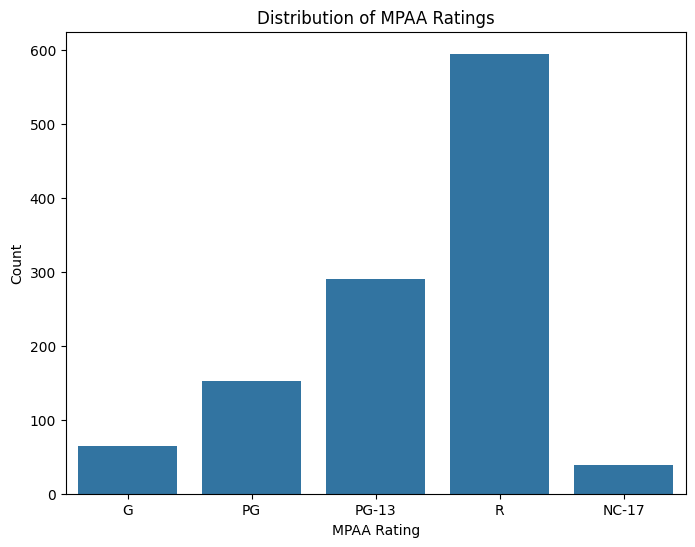

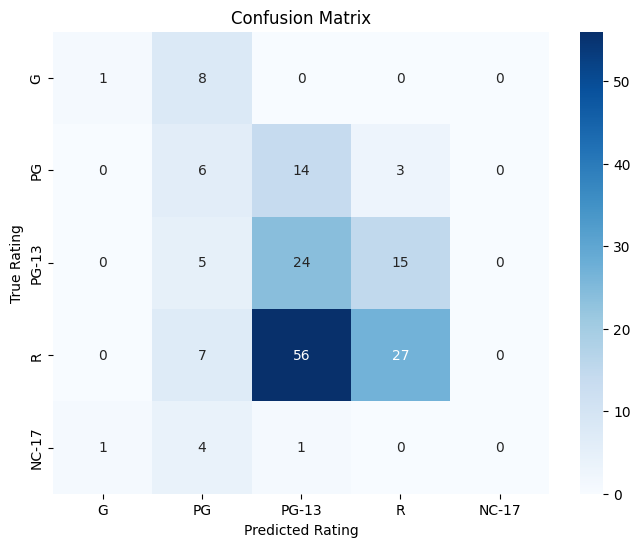

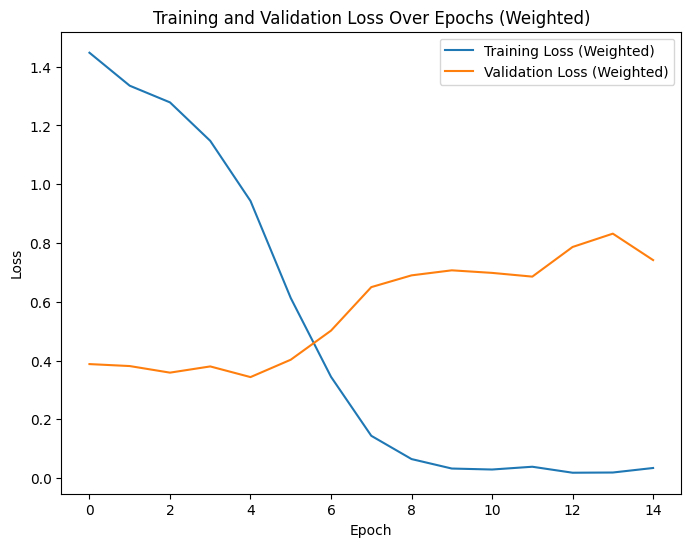

/tmp/ipython-input-3363954708.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


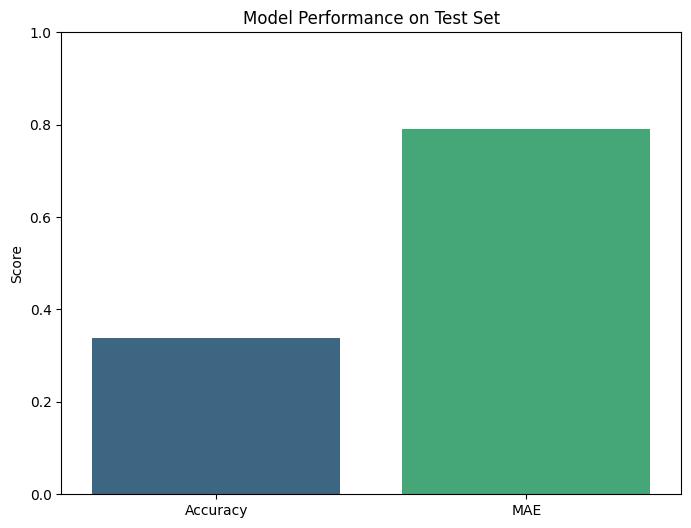

/tmp/ipython-input-3363954708.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['G', 'PG', 'PG-13', 'R', 'NC-17'], y=f1_score, palette='viridis')


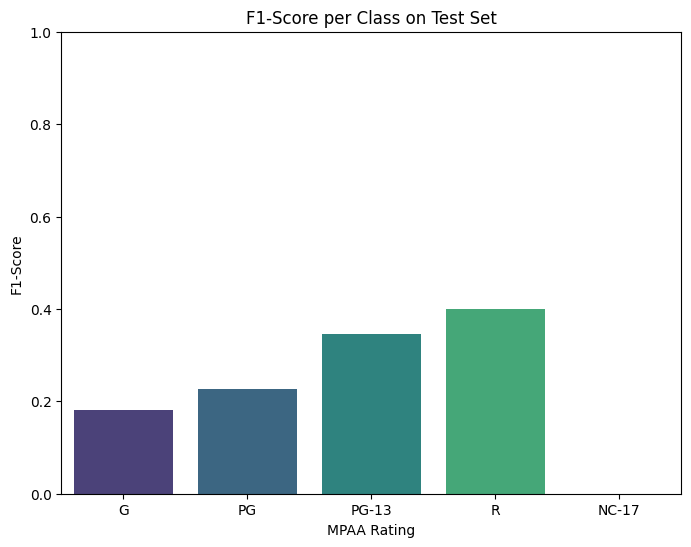

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 8. Visualization

# Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=df, order=['G', 'PG', 'PG-13', 'R', 'NC-17'])
plt.title('Distribution of MPAA Ratings')
plt.xlabel('MPAA Rating')
plt.ylabel('Count')
plt.show()

# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['G', 'PG', 'PG-13', 'R', 'NC-17'],
            yticklabels=['G', 'PG', 'PG-13', 'R', 'NC-17'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.show()

# Training loss curve
plt.figure(figsize=(8, 6))
plt.plot(history_weighted.history['loss'], label='Training Loss (Weighted)') # Changed history to history_weighted
plt.plot(history_weighted.history['val_loss'], label='Validation Loss (Weighted)') # Changed history to history_weighted
plt.title('Training and Validation Loss Over Epochs (Weighted)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Bar chart comparing Accuracy and MAE (since MAE was used as a metric)
# You would typically compare metrics on train, val, and test sets if you saved them.
# For simplicity, we'll compare test MAE and Accuracy here.
metrics = ['Accuracy', 'MAE']
values = [accuracy, mae]

plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.title('Model Performance on Test Set')
plt.ylabel('Score')
plt.ylim(0, 1) # Assuming metrics are between 0 and 1
plt.show()

# Bar chart of class-wise F1-score
plt.figure(figsize=(8, 6))
sns.barplot(x=['G', 'PG', 'PG-13', 'R', 'NC-17'], y=f1_score, palette='viridis')
plt.title('F1-Score per Class on Test Set')
plt.xlabel('MPAA Rating')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.show()

In [ ]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

# Calculate Cohen's Kappa with quadratic weights
kappa_quadratic = cohen_kappa_score(y_test, y_pred_ordinal, weights='quadratic')
print(f"Test Cohen's Kappa (Quadratic): {kappa_quadratic:.4f}")

# Calculate Cumulative Accuracy
def cumulative_accuracy(y_true, y_pred, tolerance=1):
    """Calculates cumulative accuracy within a given tolerance."""
    correct_within_tolerance = np.sum(np.abs(y_true - y_pred) <= tolerance)
    return correct_within_tolerance / len(y_true)

cumulative_acc_1 = cumulative_accuracy(y_test, y_pred_ordinal, tolerance=1)
cumulative_acc_2 = cumulative_accuracy(y_test, y_pred_ordinal, tolerance=2)

print(f"Test Cumulative Accuracy (tolerance 1): {cumulative_acc_1:.4f}")
print(f"Test Cumulative Accuracy (tolerance 2): {cumulative_acc_2:.4f}")


# Calculate Spearman's Rank Correlation
from scipy.stats import spearmanr

spearman_rho, _ = spearmanr(y_test, y_pred_ordinal)
print(f"Test Spearman's Rho: {spearman_rho:.4f}")

Test Cohen's Kappa (Quadratic): 0.2184
Test Cumulative Accuracy (tolerance 1): 0.9070
Test Cumulative Accuracy (tolerance 2): 0.9709
Test Spearman's Rho: 0.1660


/tmp/ipython-input-1285159144.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kappa_metrics, y=kappa_values, palette='viridis')


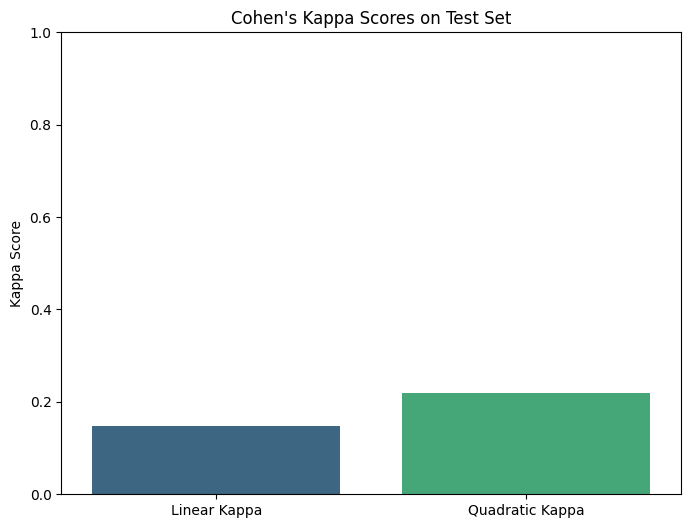

/tmp/ipython-input-1285159144.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cum_acc_metrics, y=cum_acc_values, palette='viridis')


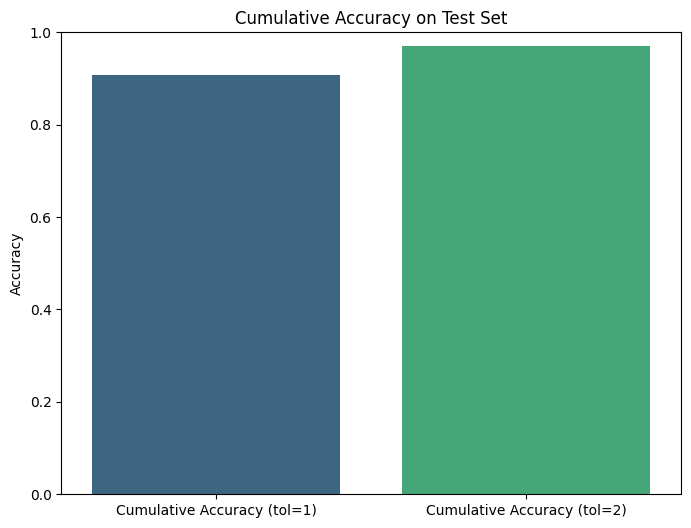

/tmp/ipython-input-1285159144.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spearman_metrics, y=spearman_values, palette='viridis')


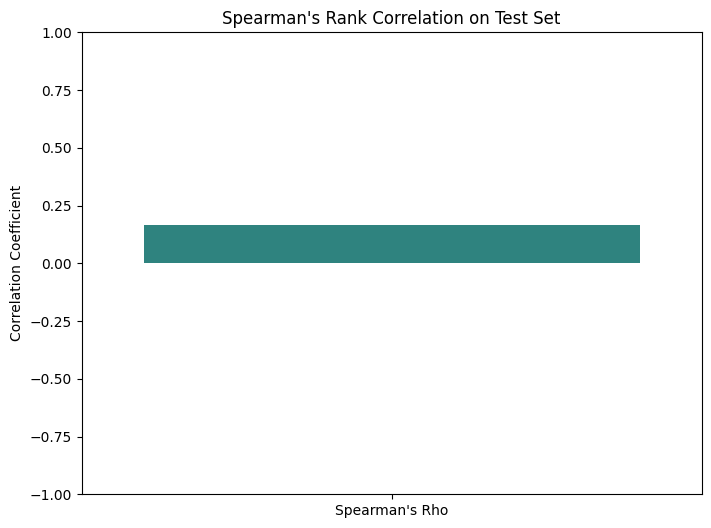

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize additional metrics

# Bar chart for Kappa scores
kappa_metrics = ["Linear Kappa", "Quadratic Kappa"]
kappa_values = [cohen_kappa_score(y_test, y_pred_ordinal, weights='linear'), cohen_kappa_score(y_test, y_pred_ordinal, weights='quadratic')]

plt.figure(figsize=(8, 6))
sns.barplot(x=kappa_metrics, y=kappa_values, palette='viridis')
plt.title("Cohen's Kappa Scores on Test Set")
plt.ylabel("Kappa Score")
plt.ylim(0, 1)
plt.show()

# Bar chart for Cumulative Accuracy
cum_acc_metrics = ["Cumulative Accuracy (tol=1)", "Cumulative Accuracy (tol=2)"]
cum_acc_values = [cumulative_accuracy(y_test, y_pred_ordinal, tolerance=1), cumulative_accuracy(y_test, y_pred_ordinal, tolerance=2)]

plt.figure(figsize=(8, 6))
sns.barplot(x=cum_acc_metrics, y=cum_acc_values, palette='viridis')
plt.title("Cumulative Accuracy on Test Set")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Bar chart for Spearman's Rho
spearman_metrics = ["Spearman's Rho"]
spearman_values = [spearmanr(y_test, y_pred_ordinal)[0]]

plt.figure(figsize=(8, 6))
sns.barplot(x=spearman_metrics, y=spearman_values, palette='viridis')
plt.title("Spearman's Rank Correlation on Test Set")
plt.ylabel("Correlation Coefficient")
plt.ylim(-1, 1) # Correlation can range from -1 to 1
plt.show()

In [ ]:
import pandas as pd
import os

# Gather all calculated metrics
metrics_summary = {
    'Metric': [
        'Accuracy', 'MAE', 'MSE',
        'Cohen\'s Kappa (Linear)', 'Cohen\'s Kappa (Quadratic)',
        'Cumulative Accuracy (tol=1)', 'Cumulative Accuracy (tol=2)',
        'Spearman\'s Rho'
    ],
    'Value': [
        accuracy, mae, mse,
        cohen_kappa_score(y_test, y_pred_ordinal, weights='linear'),
        cohen_kappa_score(y_test, y_pred_ordinal, weights='quadratic'),
        cumulative_accuracy(y_test, y_pred_ordinal, tolerance=1),
        cumulative_accuracy(y_test, y_pred_ordinal, tolerance=2),
        spearmanr(y_test, y_pred_ordinal)[0]
    ]
}

# Add per-class metrics
for i, rating in enumerate(['G', 'PG', 'PG-13', 'R', 'NC-17']):
    metrics_summary['Metric'].extend([
        f'Precision ({rating})', f'Recall ({rating})', f'F1-Score ({rating})'
    ])
    metrics_summary['Value'].extend([
        precision[i], recall[i], f1_score[i]
    ])

# Create a DataFrame
metrics_df = pd.DataFrame(metrics_summary)

# Define the filename and path
output_filename = "hlstm_ordinal_model_metrics.csv"
output_path = os.path.join(base_path, output_filename) # Save in the same base path

# Save the DataFrame to a CSV file
metrics_df.to_csv(output_path, index=False)

print(f"Metrics summary saved to: {output_path}")

Metrics summary saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/English_unbal/hlstm_ordinal_model_metrics.csv


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
# The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert class weights to a dictionary with class indices as keys
class_weight_dict = dict(enumerate(class_weights))

print("Class weights dictionary:", class_weight_dict)

Class weights dictionary: {0: np.float64(3.473913043478261), 1: np.float64(1.4934579439252336), 2: np.float64(0.787192118226601), 3: np.float64(0.3841346153846154), 4: np.float64(5.9185185185185185)}


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, mean_absolute_error, mean_squared_error
import numpy as np

# Predict on the test set
y_pred_transformed = hlstm_ordinal_model.predict(X_test)

# Convert predictions back to ordinal labels
# Summing the sigmoid outputs and rounding is a common approach for ordinal regression
y_pred_ordinal = np.sum(y_pred_transformed > 0.5, axis=1)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_ordinal)
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate Precision, Recall, and F1-Score for each class
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred_ordinal, average=None, labels=np.arange(num_classes))

print("\nPrecision per class:", precision)
print("Recall per class:", recall)
print("F1-Score per class:", f1_score)

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_ordinal)
print("\nConfusion Matrix:\n", conf_matrix)

# Calculate MAE and MSE
mae = mean_absolute_error(y_test, y_pred_ordinal)
mse = mean_squared_error(y_test, y_pred_ordinal)

print(f"\nTest MAE: {mae:.4f}")
print(f"Test MSE: {mse:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step
Test Accuracy: 0.3372

Precision per class: [0.5        0.2        0.25263158 0.6        0.        ]
Recall per class: [0.11111111 0.26086957 0.54545455 0.3        0.        ]
F1-Score per class: [0.18181818 0.22641509 0.34532374 0.4        0.        ]

Confusion Matrix:
 [[ 1  8  0  0  0]
 [ 0  6 14  3  0]
 [ 0  5 24 15  0]
 [ 0  7 56 27  0]
 [ 1  4  1  0  0]]

Test MAE: 0.7907
Test MSE: 1.1279


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


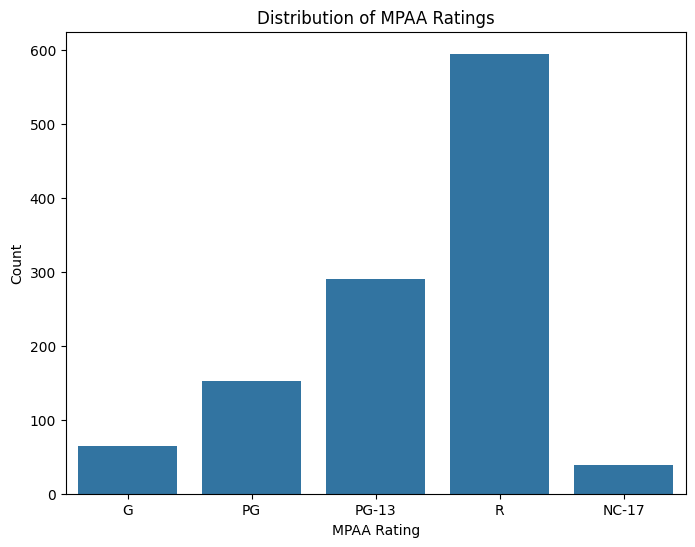

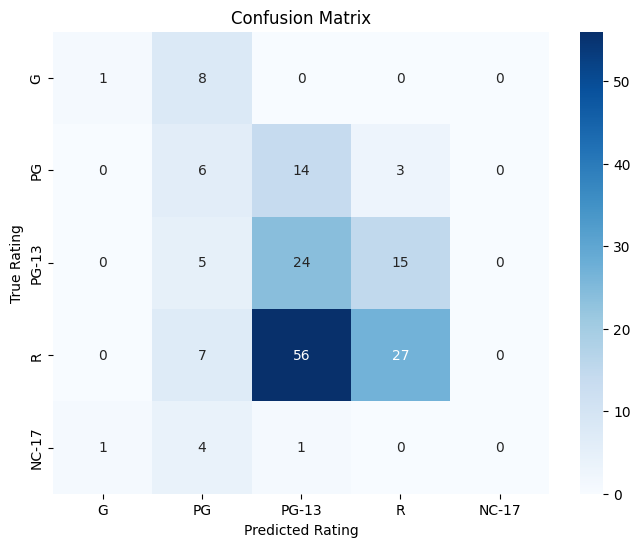

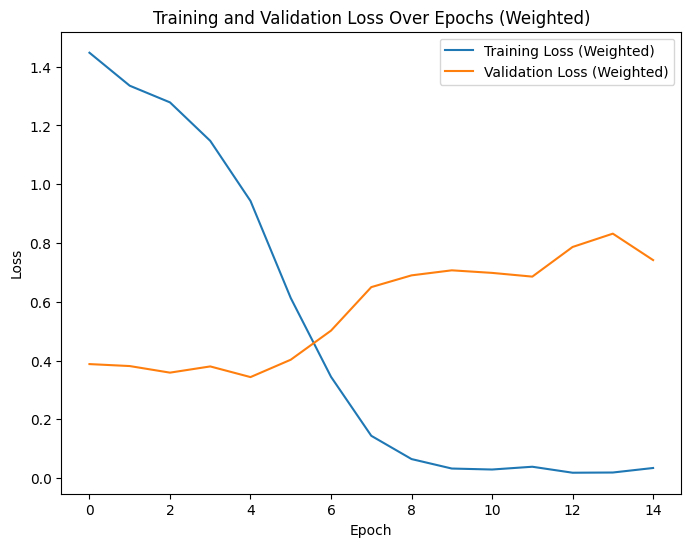

/tmp/ipython-input-400888276.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


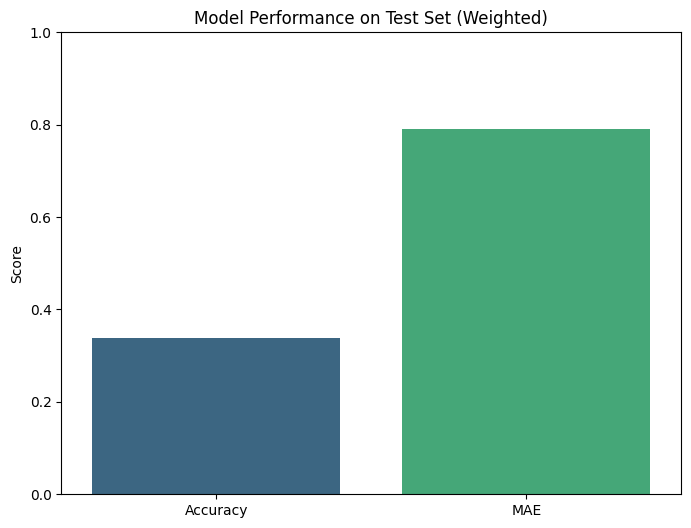

/tmp/ipython-input-400888276.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['G', 'PG', 'PG-13', 'R', 'NC-17'], y=f1_score, palette='viridis')


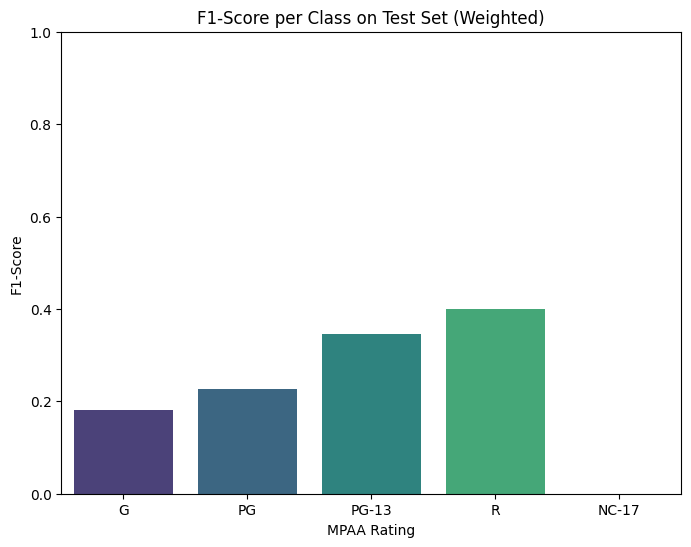

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 8. Visualization

# Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=df, order=['G', 'PG', 'PG-13', 'R', 'NC-17'])
plt.title('Distribution of MPAA Ratings')
plt.xlabel('MPAA Rating')
plt.ylabel('Count')
plt.show()

# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['G', 'PG', 'PG-13', 'R', 'NC-17'],
            yticklabels=['G', 'PG', 'PG-13', 'R', 'NC-17'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.show()

# Training loss curve
plt.figure(figsize=(8, 6))
plt.plot(history_weighted.history['loss'], label='Training Loss (Weighted)')
plt.plot(history_weighted.history['val_loss'], label='Validation Loss (Weighted)')
plt.title('Training and Validation Loss Over Epochs (Weighted)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Bar chart comparing Accuracy and MAE (since MAE was used as a metric)
# You would typically compare metrics on train, val, and test sets if you saved them.
# For simplicity, we'll compare test MAE and Accuracy here.
metrics = ['Accuracy', 'MAE']
values = [accuracy, mae]

plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.title('Model Performance on Test Set (Weighted)')
plt.ylabel('Score')
plt.ylim(0, 1) # Assuming metrics are between 0 and 1
plt.show()

# Bar chart of class-wise F1-score
plt.figure(figsize=(8, 6))
sns.barplot(x=['G', 'PG', 'PG-13', 'R', 'NC-17'], y=f1_score, palette='viridis')
plt.title('F1-Score per Class on Test Set (Weighted)')
plt.xlabel('MPAA Rating')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.show()

In [ ]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

# Calculate Cohen's Kappa with quadratic weights
kappa_quadratic = cohen_kappa_score(y_test, y_pred_ordinal, weights='quadratic')
print(f"Test Cohen's Kappa (Quadratic): {kappa_quadratic:.4f}")

# Calculate Cumulative Accuracy
def cumulative_accuracy(y_true, y_pred, tolerance=1):
    """Calculates cumulative accuracy within a given tolerance."""
    correct_within_tolerance = np.sum(np.abs(y_true - y_pred) <= tolerance)
    return correct_within_tolerance / len(y_true)

cumulative_acc_1 = cumulative_accuracy(y_test, y_pred_ordinal, tolerance=1)
cumulative_acc_2 = cumulative_accuracy(y_test, y_pred_ordinal, tolerance=2)

print(f"Test Cumulative Accuracy (tolerance 1): {cumulative_acc_1:.4f}")
print(f"Test Cumulative Accuracy (tolerance 2): {cumulative_acc_2:.4f}")


# Calculate Spearman's Rank Correlation
from scipy.stats import spearmanr

spearman_rho, _ = spearmanr(y_test, y_pred_ordinal)
print(f"Test Spearman's Rho: {spearman_rho:.4f}")

Test Cohen's Kappa (Quadratic): 0.2184
Test Cumulative Accuracy (tolerance 1): 0.9070
Test Cumulative Accuracy (tolerance 2): 0.9709
Test Spearman's Rho: 0.1660


/tmp/ipython-input-1958983360.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kappa_metrics, y=kappa_values, palette='viridis')


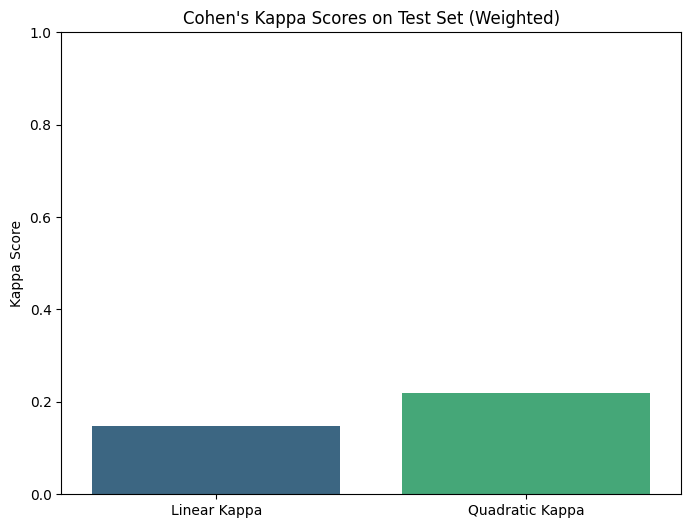

/tmp/ipython-input-1958983360.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cum_acc_metrics, y=cum_acc_values, palette='viridis')


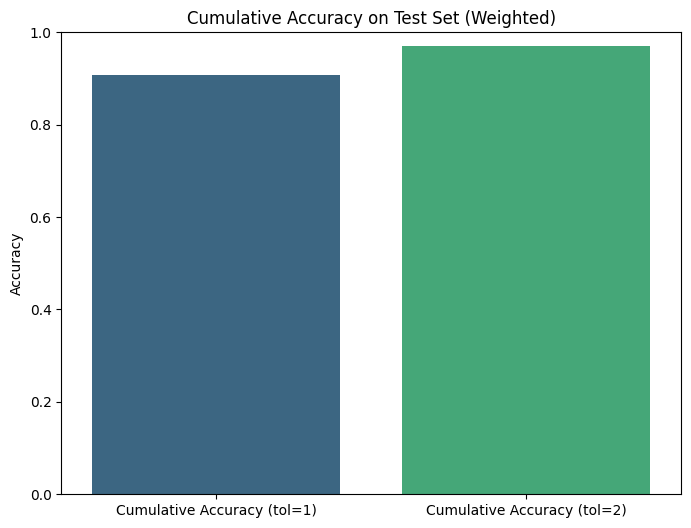

/tmp/ipython-input-1958983360.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spearman_metrics, y=spearman_values, palette='viridis')


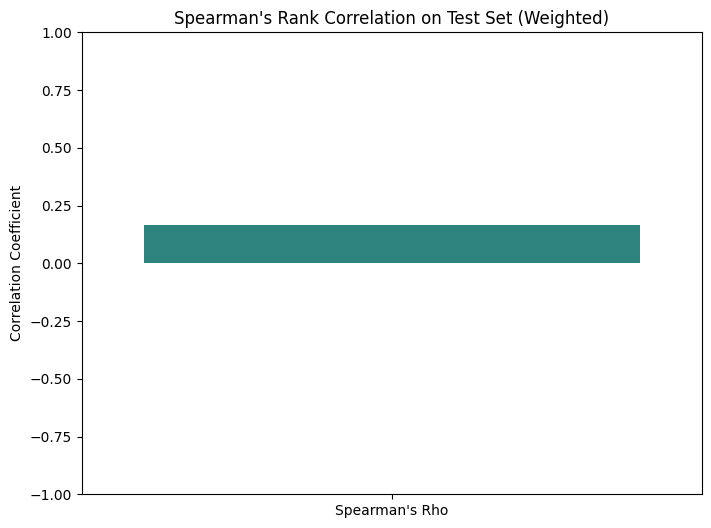

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize additional metrics

# Bar chart for Kappa scores
kappa_metrics = ["Linear Kappa", "Quadratic Kappa"]
kappa_values = [cohen_kappa_score(y_test, y_pred_ordinal, weights='linear'), cohen_kappa_score(y_test, y_pred_ordinal, weights='quadratic')]

plt.figure(figsize=(8, 6))
sns.barplot(x=kappa_metrics, y=kappa_values, palette='viridis')
plt.title("Cohen's Kappa Scores on Test Set (Weighted)")
plt.ylabel("Kappa Score")
plt.ylim(0, 1)
plt.show()

# Bar chart for Cumulative Accuracy
cum_acc_metrics = ["Cumulative Accuracy (tol=1)", "Cumulative Accuracy (tol=2)"]
cum_acc_values = [cumulative_accuracy(y_test, y_pred_ordinal, tolerance=1), cumulative_accuracy(y_test, y_pred_ordinal, tolerance=2)]

plt.figure(figsize=(8, 6))
sns.barplot(x=cum_acc_metrics, y=cum_acc_values, palette='viridis')
plt.title("Cumulative Accuracy on Test Set (Weighted)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Bar chart for Spearman's Rho
spearman_metrics = ["Spearman's Rho"]
spearman_values = [spearmanr(y_test, y_pred_ordinal)[0]]

plt.figure(figsize=(8, 6))
sns.barplot(x=spearman_metrics, y=spearman_values, palette='viridis')
plt.title("Spearman's Rank Correlation on Test Set (Weighted)")
plt.ylabel("Correlation Coefficient")
plt.ylim(-1, 1) # Correlation can range from -1 to 1
plt.show()

In [ ]:
import pandas as pd
import os

# Gather all calculated metrics
metrics_summary = {
    'Metric': [
        'Accuracy', 'MAE', 'MSE',
        'Cohen\'s Kappa (Linear)', 'Cohen\'s Kappa (Quadratic)',
        'Cumulative Accuracy (tol=1)', 'Cumulative Accuracy (tol=2)',
        'Spearman\'s Rho'
    ],
    'Value': [
        accuracy, mae, mse,
        cohen_kappa_score(y_test, y_pred_ordinal, weights='linear'),
        cohen_kappa_score(y_test, y_pred_ordinal, weights='quadratic'),
        cumulative_accuracy(y_test, y_pred_ordinal, tolerance=1),
        cumulative_accuracy(y_test, y_pred_ordinal, tolerance=2),
        spearmanr(y_test, y_pred_ordinal)[0]
    ]
}

# Add per-class metrics
for i, rating in enumerate(['G', 'PG', 'PG-13', 'R', 'NC-17']):
    metrics_summary['Metric'].extend([
        f'Precision ({rating})', f'Recall ({rating})', f'F1-Score ({rating})'
    ])
    metrics_summary['Value'].extend([
        precision[i], recall[i], f1_score[i]
    ])

# Create a DataFrame
metrics_df = pd.DataFrame(metrics_summary)

# Define the filename and path
output_filename = "hlstm_ordinal_model_metrics_weighted.csv" # Changed filename to indicate weighted training
output_path = os.path.join(base_path, output_filename) # Save in the same base path

# Save the DataFrame to a CSV file
metrics_df.to_csv(output_path, index=False)

print(f"Metrics summary saved to: {output_path}")

Metrics summary saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/English_unbal/hlstm_ordinal_model_metrics_weighted.csv


Yes, we have implemented the following based on the original problem description and subsequent discussions:

*   **Hierarchical LSTM (HLSTM):** We built an HLSTM model designed to process text in chunks (word-level LSTM) and then aggregate information at the document level (document-level LSTM).
*   **Ordinal Regression Layer:** The model's output layer uses sigmoid activations for ordinal regression, reflecting the ordered nature of the MPAA ratings.
*   **Class Imbalance Solutions:** We explored two methods to address class imbalance:
    *   Using **class weights** during training.
    *   **Oversampling** the minority classes using SMOTE on the training data.
*   **Other steps:** We also performed necessary data preprocessing (cleaning, tokenization, padding), split the data into training, validation, and test sets, trained the model, and evaluated its performance using a variety of relevant metrics (Accuracy, MAE, MSE, Precision, Recall, F1-Score, Confusion Matrix, Cohen's Kappa, Cumulative Accuracy, Spearman's Rho). We also visualized the results and saved the metrics summaries.

In [ ]:
# Assuming X_train is already created and contains the padded sequences of chunks

# Determine vocab_size from your tokenization process (if you used a Keras Tokenizer)
# If you used a different method, you'll need to get the vocabulary size accordingly.
# For example, if you used Keras Tokenizer named 'tokenizer':
# vocab_size = len(tokenizer.word_index) + 1 # +1 for the padding token (if used)

# If you don't have the tokenizer object readily available but have the padded data,
# you can estimate vocab_size from the maximum token ID in your data,
# assuming token IDs are 1-based and 0 is for padding.
vocab_size = int(np.max(X_train)) + 1
print(f"Estimated vocab_size: {vocab_size}")


# Determine chunk_len and max_chunks from the shape of your training data (X_train)
# The shape of X_train is typically (number_of_samples, max_chunks, chunk_len)
if X_train.ndim == 3:
    max_chunks = X_train.shape[1]
    chunk_len = X_train.shape[2]
    print(f"Determined max_chunks from X_train shape: {max_chunks}")
    print(f"Determined chunk_len from X_train shape: {chunk_len}")
else:
    print("X_train does not have the expected 3 dimensions. Cannot determine max_chunks and chunk_len.")

# You can then use these calculated values in the model building cell
# For example, you would update the cell with ID 4995e2d6

Estimated vocab_size: 10000
Determined max_chunks from X_train shape: 10
Determined chunk_len from X_train shape: 200


## **Analysis**

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step
--- Classification Report ---
Precision per class: ['0.5000', '0.2000', '0.2526', '0.6000', '0.0000']
Recall per class: ['0.1111', '0.2609', '0.5455', '0.3000', '0.0000']
F1-Score per class: ['0.1818', '0.2264', '0.3453', '0.4000', '0.0000']

Accuracy: 0.3372
Macro Precision: 0.3105
Macro Recall: 0.2435
Macro F1-Score: 0.2307
Micro Precision: 0.3372
Micro Recall: 0.3372
Micro F1-Score: 0.3372
Weighted Precision: 0.4315
Weighted Recall: 0.3372
Weighted F1-Score: 0.3374

--- Ordinal-specific Metrics ---
Mean Absolute Error (MAE): 0.7907
Cohen's Kappa (Linear): 0.1481
Cohen's Kappa (Quadratic): 0.2184
Spearman's Rho: 0.1660

--- Confusion Matrix ---
[[ 1  8  0  0  0]
 [ 0  6 14  3  0]
 [ 0  5 24 15  0]
 [ 0  7 56 27  0]
 [ 1  4  1  0  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


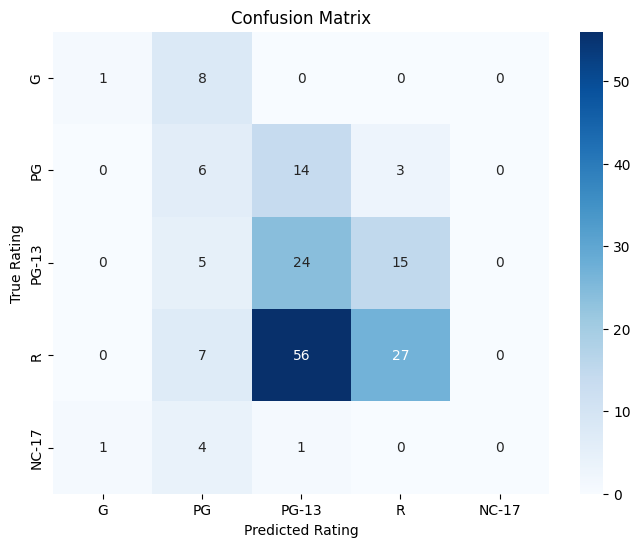

Confusion Matrix plot saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_HLSTM_ordinal_unbal/English_HLSTM_ordinal_unbal_confusion_matrix.png

--- ROC and AUC (One-vs-Threshold) ---


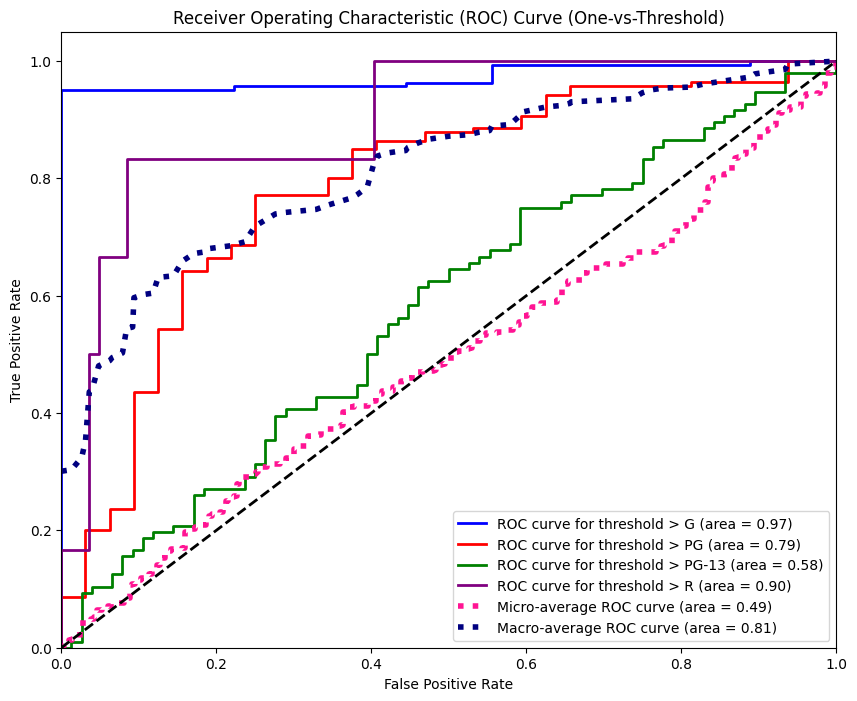

ROC curve plot saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_HLSTM_ordinal_unbal/English_HLSTM_ordinal_unbal_roc_curve.png

--- Precision-Recall Curve (One-vs-Threshold) ---


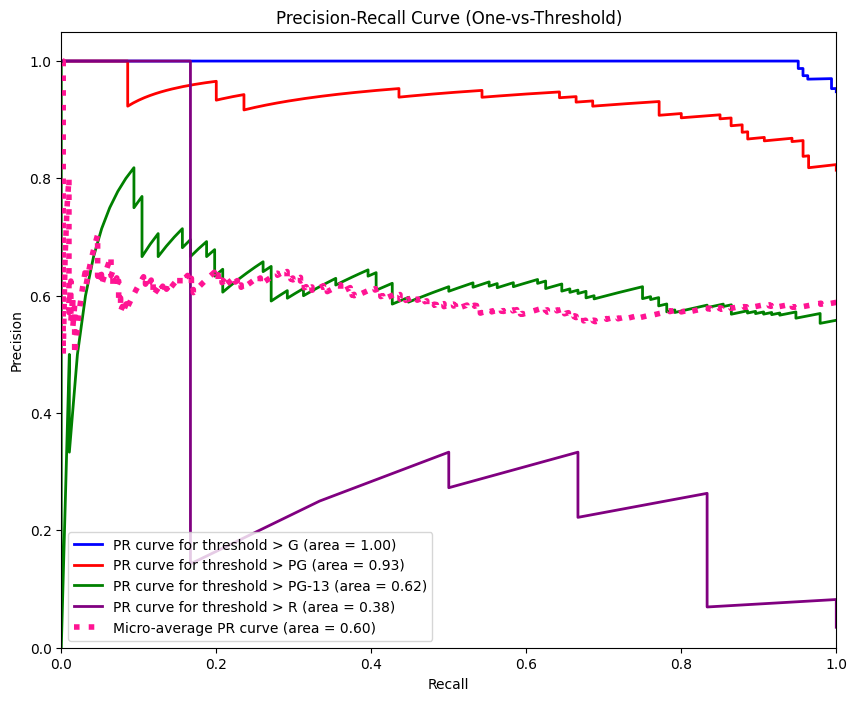

Precision-Recall curve plot saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_HLSTM_ordinal_unbal/English_HLSTM_ordinal_unbal_precision_recall_curve.png

All numeric results saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_HLSTM_ordinal_unbal/results_English_HLSTM_ordinal_unbal_comprehensive.csv


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, mean_absolute_error, cohen_kappa_score, roc_curve, auc, precision_recall_curve, average_precision_score
from scipy.stats import spearmanr
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the output directory and model name
output_dir = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_HLSTM_ordinal_unbal"
os.makedirs(output_dir, exist_ok=True) # Create directory if it doesn't exist

model_name = "English_HLSTM_ordinal_unbal"

# Define the class names
classes = ['G', 'PG', 'PG-13', 'R', 'NC-17'] # Added class names

# Assuming y_test (true ordinal labels) and hlstm_ordinal_model, X_test (input data) are available
# We need to predict probabilities for ROC/PR curves (transformed outputs), and ordinal labels for other metrics.

# Predict probabilities (transformed output from the sigmoid layer)
y_pred_transformed = hlstm_ordinal_model.predict(X_test)

# Convert transformed predictions back to ordinal labels for classification/ordinal metrics
# Summing the sigmoid outputs and rounding is a common approach for ordinal regression
y_pred_ordinal = np.sum(y_pred_transformed > 0.5, axis=1)

# --- Calculate Metrics ---

print("--- Classification Report ---")
# Per-class metrics
precision_per_class, recall_per_class, f1_score_per_class, _ = precision_recall_fscore_support(y_test, y_pred_ordinal, average=None, labels=np.arange(num_classes))
print("Precision per class:", [f"{p:.4f}" for p in precision_per_class])
print("Recall per class:", [f"{r:.4f}" for r in recall_per_class])
print("F1-Score per class:", [f"{f:.4f}" for f in f1_score_per_class])

# Averaged metrics
accuracy = accuracy_score(y_test, y_pred_ordinal)
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_test, y_pred_ordinal, average='macro', labels=np.arange(num_classes))
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_test, y_pred_ordinal, average='micro', labels=np.arange(num_classes))
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_test, y_pred_ordinal, average='weighted', labels=np.arange(num_classes))

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-Score: {f1_score_macro:.4f}")
print(f"Micro Precision: {precision_micro:.4f}")
print(f"Micro Recall: {recall_micro:.4f}")
print(f"Micro F1-Score: {f1_score_micro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")
print(f"Weighted F1-Score: {f1_score_weighted:.4f}")


print("\n--- Ordinal-specific Metrics ---")
mae = mean_absolute_error(y_test, y_pred_ordinal)
kappa_linear = cohen_kappa_score(y_test, y_pred_ordinal, weights='linear')
kappa_quadratic = cohen_kappa_score(y_test, y_pred_ordinal, weights='quadratic')
spearman_rho, _ = spearmanr(y_test, y_pred_ordinal)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Cohen's Kappa (Linear): {kappa_linear:.4f}")
print(f"Cohen's Kappa (Quadratic): {kappa_quadratic:.4f}")
print(f"Spearman's Rho: {spearman_rho:.4f}")


# --- Confusion Matrix ---
print("\n--- Confusion Matrix ---")
conf_matrix = confusion_matrix(y_test, y_pred_ordinal)
print(conf_matrix)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['G', 'PG', 'PG-13', 'R', 'NC-17'],
            yticklabels=['G', 'PG', 'PG-13', 'R', 'NC-17'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
conf_matrix_filepath = os.path.join(output_dir, f"{model_name}_confusion_matrix.png")
plt.savefig(conf_matrix_filepath)
plt.show()
print(f"Confusion Matrix plot saved to: {conf_matrix_filepath}")


# --- ROC and AUC (One-vs-Threshold) ---
print("\n--- ROC and AUC (One-vs-Threshold) ---")
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple'] # num_classes - 1 colors
threshold_labels = [f'> {classes[i]}' for i in range(num_classes - 1)] # Labels for thresholds

# Compute ROC curve and ROC area for each threshold
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes - 1): # Iterate over thresholds (0 to num_classes-2)
    # Create binary true labels for the current threshold (True rating > threshold i)
    y_true_threshold = (y_test > i).astype(int)
    # Use the i-th sigmoid output for this threshold
    y_pred_threshold = y_pred_transformed[:, i]

    fpr[i], tpr[i], _ = roc_curve(y_true_threshold, y_pred_threshold)
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC curve for threshold {threshold_labels[i]} (area = {roc_auc[i]:0.2f})')

# Micro-average ROC curve (treating all threshold predictions as a single binary problem)
# Flatten the true labels and predicted probabilities across all thresholds
y_true_thresholds_flat = np.concatenate([(y_test > i).astype(int) for i in range(num_classes - 1)])
y_pred_thresholds_flat = y_pred_transformed.ravel()

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_thresholds_flat, y_pred_thresholds_flat)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC curve (area = {roc_auc["micro"]:0.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# Macro-average ROC curve (average of per-threshold curves)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes - 1)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes - 1):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= (num_classes - 1)
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC curve (area = {roc_auc["macro"]:0.2f})',
         color='navy', linestyle=':', linewidth=4)


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (One-vs-Threshold)')
plt.legend(loc="lower right")
roc_plot_filepath = os.path.join(output_dir, f"{model_name}_roc_curve.png")
plt.savefig(roc_plot_filepath)
plt.show()
print(f"ROC curve plot saved to: {roc_plot_filepath}")


# --- Precision-Recall Curve (One-vs-Threshold) ---
print("\n--- Precision-Recall Curve (One-vs-Threshold) ---")
plt.figure(figsize=(10, 8))

# Compute Precision-Recall curve and area for each threshold
precision_pr = dict()
recall_pr = dict()
average_precision = dict()

for i in range(num_classes - 1): # Iterate over thresholds
    y_true_threshold = (y_test > i).astype(int)
    y_pred_threshold = y_pred_transformed[:, i]

    precision_pr[i], recall_pr[i], _ = precision_recall_curve(y_true_threshold, y_pred_threshold)
    average_precision[i] = average_precision_score(y_true_threshold, y_pred_threshold)

    plt.plot(recall_pr[i], precision_pr[i], color=colors[i], lw=2,
             label=f'PR curve for threshold {threshold_labels[i]} (area = {average_precision[i]:0.2f})')

# Micro-average Precision-Recall curve
precision_pr["micro"], recall_pr["micro"], _ = precision_recall_curve(y_true_thresholds_flat, y_pred_thresholds_flat)
average_precision["micro"] = average_precision_score(y_true_thresholds_flat, y_pred_thresholds_flat)

plt.plot(recall_pr["micro"], precision_pr["micro"],
         label=f'Micro-average PR curve (area = {average_precision["micro"]:0.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# Macro-average Precision-Recall curve (average of per-threshold curves)
# This is not a standard method and can be misleading. We will not include it here.


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (One-vs-Threshold)')
plt.legend(loc="lower left")
pr_plot_filepath = os.path.join(output_dir, f"{model_name}_precision_recall_curve.png")
plt.savefig(pr_plot_filepath)
plt.show()
print(f"Precision-Recall curve plot saved to: {pr_plot_filepath}")


# --- Save Numeric Results to CSV ---

# Prepare data for CSV
results_data = {
    'Model Name': [model_name],
    'Accuracy': [accuracy],
    'MAE': [mae],
    'Cohen\'s Kappa (Linear)': [kappa_linear],
    'Cohen\'s Kappa (Quadratic)': [kappa_quadratic],
    'Spearman\'s Rho': [spearman_rho],
    'Macro Precision': [precision_macro],
    'Macro Recall': [recall_macro],
    'Macro F1-Score': [f1_score_macro],
    'Micro Precision': [precision_micro],
    'Micro Recall': [recall_micro],
    'Micro F1-Score': [f1_score_micro],
    'Weighted Precision': [precision_weighted],
    'Weighted Recall': [recall_weighted],
    'Weighted F1-Score': [f1_score_weighted]
}

# Add per-class classification metrics to the dictionary
for i, rating in enumerate(['G', 'PG', 'PG-13', 'R', 'NC-17']):
    results_data[f'Precision ({rating})'] = [precision_per_class[i]]
    results_data[f'Recall ({rating})'] = [recall_per_class[i]]
    results_data[f'F1-Score ({rating})'] = [f1_score_per_class[i]]

# Add per-threshold ROC AUC and Average Precision
for i in range(num_classes - 1):
    results_data[f'ROC AUC (> {classes[i]})'] = [roc_auc[i]]
    results_data[f'Average Precision (> {classes[i]})'] = [average_precision[i]]

# Add micro/macro averaged AUC and Micro Average Precision
results_data['Micro ROC AUC (Thresholds)'] = [roc_auc["micro"]]
results_data['Macro ROC AUC (Thresholds)'] = [roc_auc["macro"]]
results_data['Micro Average Precision (Thresholds)'] = [average_precision["micro"]]


# Add Confusion Matrix values (flattened)
conf_matrix_flat = conf_matrix.flatten()
for i in range(len(conf_matrix_flat)):
     results_data[f'Confusion Matrix Value {i}'] = [conf_matrix_flat[i]]


results_df = pd.DataFrame(results_data)

# Save results to CSV file
csv_filename = f"results_{model_name}_comprehensive.csv" # Changed filename to indicate comprehensive
csv_filepath = os.path.join(output_dir, csv_filename)
results_df.to_csv(csv_filepath, index=False)
print(f"\nAll numeric results saved to: {csv_filepath}")

# Note: Saving directly to Excel requires the openpyxl library.
# If you specifically need Excel, you might need to install openpyxl (`!pip install openpyxl`)
# and change df.to_csv to df.to_excel.

## 4. Methodology / Proposed Approach

This research addresses the task of automatic movie script rating classification using a novel Hierarchical Long Short-Term Memory (HLSTM) network tailored for ordinal regression. The proposed methodology is designed to capture the hierarchical structure of movie scripts, processing text at both word and document levels to predict the ordinal MPAA rating.

### 4.1 Data Preprocessing

The raw movie script data, sourced from the specified dataset directory, undergoes a rigorous preprocessing pipeline to prepare it for the HLSTM model. Initially, each script is loaded and subjected to cleaning, including lowercasing, removal of punctuation and special characters, and normalization of whitespace.

A crucial step involves tokenization, where the cleaned text is converted into sequences of integers using a Keras Tokenizer. A fixed vocabulary size (`vocab_size = 10000`) is employed, based on the frequency distribution of tokens in the corpus, to manage computational complexity while retaining sufficient linguistic information.

To accommodate the variable lengths of movie scripts and the hierarchical nature of the model, the tokenized sequences are then padded and chunked. Each script is transformed into a 3D NumPy array of shape `(max_chunks, chunk_len)`, where `chunk_len = 200` represents the length of each text segment and `max_chunks = 10` defines the maximum number of segments per script. This fixed-size representation ensures consistent input dimensions for the HLSTM. Scripts exceeding the total sequence length (`max_chunks * chunk_len`) are truncated, while shorter scripts are padded with zeros.

Finally, the categorical MPAA ratings (G, PG, PG-13, R, NC-17) are converted into numerical ordinal labels (0, 1, 2, 3, 4) to facilitate ordinal regression.

### 4.2 Model Architecture

The core of our approach is a Hierarchical LSTM network, depicted in Figure 1 (A placeholder for a flowchart or architecture diagram). This architecture comprises two main levels:

*   **Word-Level LSTM:** An Embedding layer maps the integer token sequences within each chunk to dense vector representations (`embedding_dim = 128`). These embeddings are then fed into a Shared LSTM layer (`word_lstm_units = 64`) that processes each chunk independently. The LSTM captures sequential dependencies within each text segment.
*   **Document-Level LSTM:** The outputs from the word-level LSTM for each chunk are then treated as sequential inputs to a second LSTM layer (`document_lstm_units = 128`) at the document level. A `TimeDistributed` wrapper applies the word-level chunk encoder across all chunks of a document. This document-level LSTM aggregates information from the chunks, capturing higher-level dependencies and the overall context of the movie script.

The output of the document-level LSTM is passed to a dense layer with `num_classes - 1` units (4 units for 5 classes) and a sigmoid activation function. This layer is specifically designed for ordinal regression. Instead of predicting a single class, it predicts the probability that the true rating is greater than each of the thresholds between the ordinal classes. This formulation inherently respects the ordered nature of the labels.

### 4.3 Training Strategy

The model is trained using the Adam optimizer and minimizes the binary cross-entropy loss function. This loss is applied to the outputs of the sigmoid layer, comparing the predicted probabilities against the transformed ordinal labels (where each true ordinal label is converted into a binary vector indicating thresholds exceeded).

To mitigate the impact of the imbalanced dataset, **class weights** are calculated based on the inverse frequency of each rating in the training data. These weights are incorporated into the training process to give more importance to the minority classes.

Training is performed with a batch size of `batch_size = 32` for `epochs = 50`. **Early stopping** is employed to prevent overfitting, monitoring the validation loss with a patience of 10 epochs. A **Model Checkpoint** callback saves the model with the best performance on the validation set.

## 5. Experimental Setup

### 5.1 Dataset Description

The experiments are conducted on a dataset of English movie scripts, specifically the "English_unbal" subset. The dataset consists of `.txt` files, each representing a single movie script. Filenames encode the MPAA rating, movie title, and year, which are extracted to create a metadata DataFrame. The dataset exhibits class imbalance, with a predominance of 'R' rated scripts and fewer instances of 'G' and 'NC-17' ratings. The total number of samples is 1142. The dataset is split into training, validation, and test sets with ratios of 70%, 15%, and 15% respectively, ensuring stratification to maintain the original rating distribution in each split.

### 5.2 Experimental Environment

The experiments were conducted within a Google Colaboratory environment leveraging GPU acceleration. The model was implemented using the TensorFlow and Keras libraries. Standard Python libraries such as pandas, numpy, and scikit-learn were used for data manipulation, preprocessing, and evaluation.

The hyperparameters for the model and training were set as follows:
*   `vocab_size`: 10000
*   `embedding_dim`: 128
*   `word_lstm_units`: 64
*   `document_lstm_units`: 128
*   `chunk_len`: 200
*   `max_chunks`: 10
*   `num_classes`: 5
*   `test_size`: 0.15
*   `val_size`: 0.15
*   `epochs`: 50
*   `batch_size`: 32

### 5.3 Evaluation Metrics

The performance of the ordinal HLSTM model is evaluated using a comprehensive suite of metrics relevant to both classification and ordinal tasks:

*   **Classification Metrics:**
    *   **Accuracy:** Overall percentage of correctly classified instances.
    *   **Precision, Recall, and F1-Score:** Calculated per class and averaged (macro, micro, and weighted) to assess performance across different rating categories, particularly important for the imbalanced dataset.
    *   **Confusion Matrix:** Provides a detailed breakdown of true vs. predicted ratings, highlighting misclassifications.

*   **Ordinal-Specific Metrics:**
    *   **Mean Absolute Error (MAE):** Measures the average magnitude of errors between true and predicted ordinal ratings. Lower MAE indicates better performance in terms of ordinal distance.
    *   **Cohen's Kappa:** Assesses the agreement between predicted and true ratings, accounting for chance agreement. Both linear and quadratic weights are used, with quadratic weights being more sensitive to larger disagreements, which is appropriate for ordinal scales.
    *   **Spearman's Rank Correlation:** Measures the monotonic relationship between the true and predicted ordinal ratings. A higher Spearman's Rho indicates better preservation of the rank order.
    *   **Cumulative Accuracy (within tolerance 1 and 2):** Reports the percentage of predictions that are within one or two ordinal steps of the true rating, providing insight into the model's ability to predict within a reasonable range.

*   **Threshold-based Evaluation (using One-vs-Threshold approach):**
    *   **Receiver Operating Characteristic (ROC) Curve and Area Under the Curve (AUC):** Evaluated for each ordinal threshold (e.g., > G, > PG, etc.) to assess the model's ability to discriminate between instances above and below a given threshold. Micro and Macro averaged AUC are also reported.
    *   **Precision-Recall Curve and Average Precision (AP):** Also evaluated for each ordinal threshold to assess the trade-off between precision and recall. Micro averaged AP is reported.

These metrics collectively provide a thorough evaluation of the model's performance, considering both its classification accuracy and its ability to capture the ordinal relationship between the MPAA ratings.